In [ ]:
# Import Libraries

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_PATH = "/content/drive/MyDrive/data"

invoice_path = os.path.join(BASE_PATH, "/content/drive/MyDrive/data/invoices/train/images")

resume_path = os.path.join(BASE_PATH, "/content/drive/MyDrive/data/resumes")

id_path = os.path.join(BASE_PATH, "/content/drive/MyDrive/data/id_cards/Aadharcard/train/images")

In [ ]:
OUTPUT_PATH = "/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs"

os.makedirs(OUTPUT_PATH, exist_ok=True)

In [ ]:
# Image Loader

def load_image(image_path):
    """
    Load an image from disk.

    Parameters
    ----------
    image_path : str

    Returns
    -------
    numpy.ndarray
    """

    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Image not found : {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image

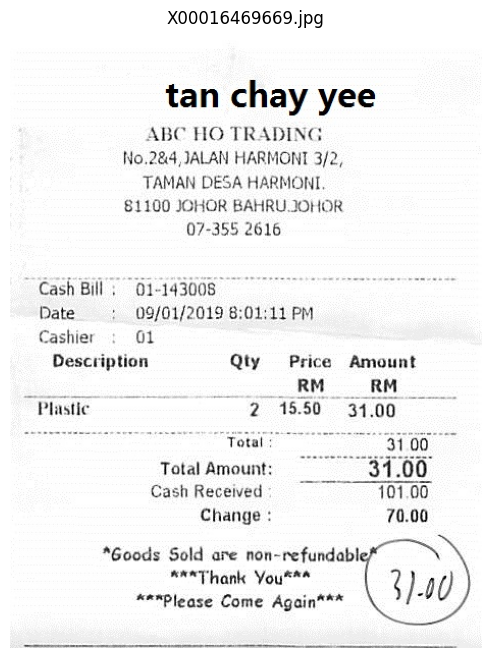

In [ ]:
# Test

sample = os.listdir(invoice_path)[0]

image = load_image(os.path.join(invoice_path, sample))

plt.figure(figsize=(8,8))

plt.imshow(image)

plt.axis("off")

plt.title(sample)

plt.show()

In [ ]:
# Resize Image

def resize_image(image,
                 width=1024):

    h, w = image.shape[:2]

    ratio = width / w

    height = int(h * ratio)

    resized = cv2.resize(image,
                         (width, height),
                         interpolation=cv2.INTER_AREA)

    return resized

(np.float64(-0.5), np.float64(1023.5), np.float64(1337.5), np.float64(-0.5))

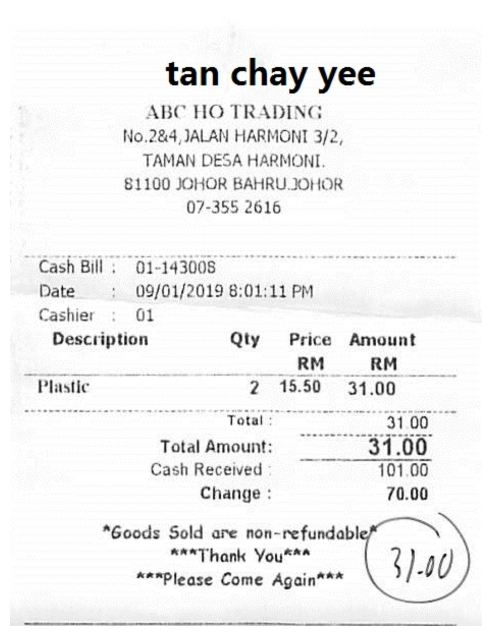

In [ ]:
# Test

resized = resize_image(image)

plt.figure(figsize=(8,8))

plt.imshow(resized)

plt.axis("off")

In [ ]:
# Convert to Grayscale

def grayscale(image):

    return cv2.cvtColor(image,
                        cv2.COLOR_RGB2GRAY)

(np.float64(-0.5), np.float64(1023.5), np.float64(1337.5), np.float64(-0.5))

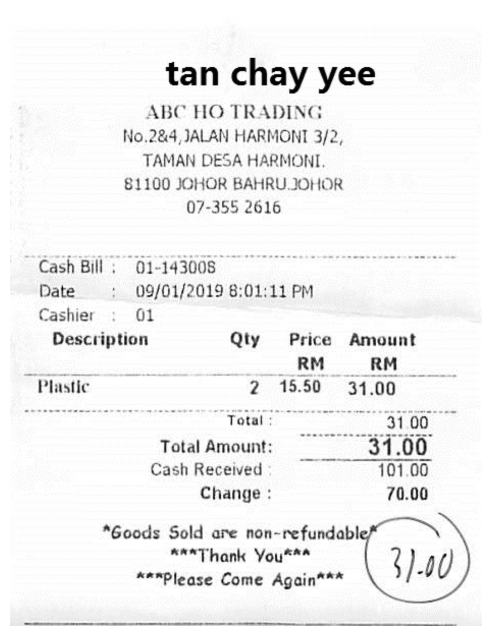

In [ ]:
# Test

gray = grayscale(resized)

plt.figure(figsize=(8,8))

plt.imshow(gray,
           cmap="gray")

plt.axis("off")

In [ ]:
# Noise Removal

def remove_noise(image):

    return cv2.fastNlMeansDenoising(
        image,
        None,
        15,
        7,
        21
    )

(np.float64(-0.5), np.float64(1023.5), np.float64(1337.5), np.float64(-0.5))

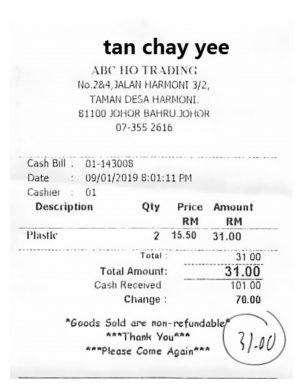

In [ ]:
# Test

noise_removed = remove_noise(gray)

plt.imshow(noise_removed,
           cmap="gray")

plt.axis("off")

In [ ]:
# Gaussian Blur

def gaussian_blur(image):

    return cv2.GaussianBlur(
        image,
        (5,5),
        0
    )

In [ ]:
# Median Blur

def median_blur(image):

    return cv2.medianBlur(
        image,
        3
    )

In [ ]:
# Bilateral Filter

def bilateral_filter(image):

    return cv2.bilateralFilter(
        image,
        9,
        75,
        75
    )

In [ ]:
# Adaptive Thresholding

def adaptive_threshold(image):
    """
    Apply adaptive Gaussian thresholding.
    """

    return cv2.adaptiveThreshold(
        image,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

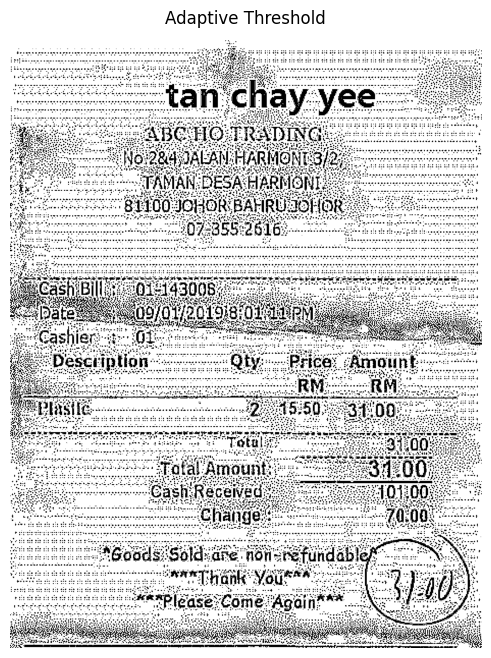

In [ ]:
# Test

adaptive = adaptive_threshold(gray)

plt.figure(figsize=(8,8))
plt.imshow(adaptive, cmap="gray")
plt.title("Adaptive Threshold")
plt.axis("off")
plt.show()

In [ ]:
# Otsu Thresholding

def otsu_threshold(image):
    """
    Apply Otsu thresholding.
    """

    _, thresh = cv2.threshold(
        image,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return thresh

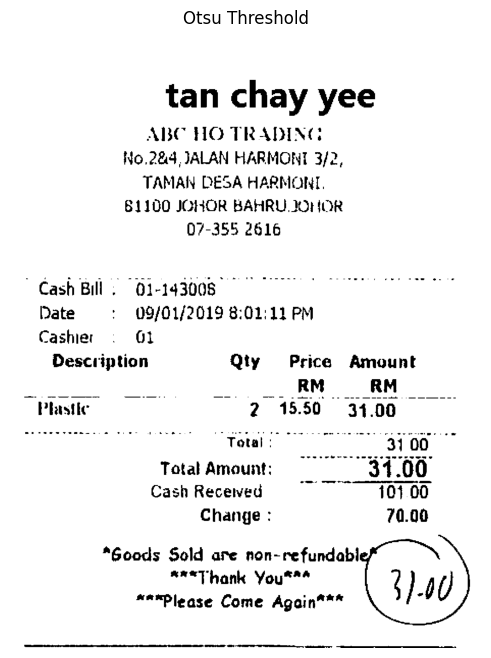

In [ ]:
# Test

otsu = otsu_threshold(gray)

plt.figure(figsize=(8,8))
plt.imshow(otsu, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")
plt.show()

In [ ]:
# Morphological Operations

def morphological_processing(image):
    """
    Perform morphological opening and closing.
    """

    kernel = np.ones((3,3), np.uint8)

    opening = cv2.morphologyEx(
        image,
        cv2.MORPH_OPEN,
        kernel
    )

    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel
    )

    return closing

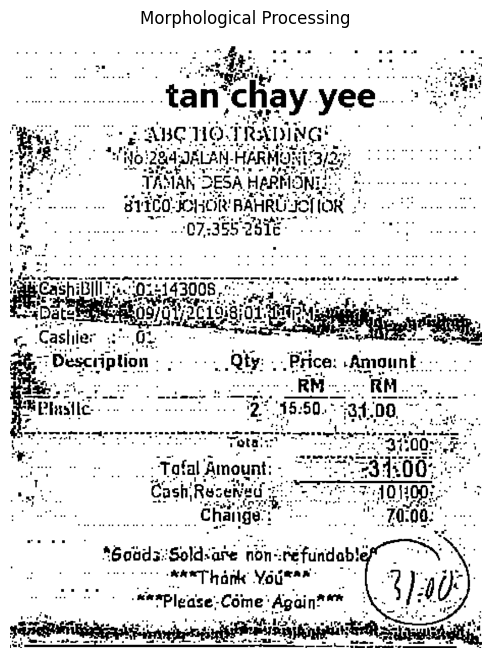

In [ ]:
# Test

morph = morphological_processing(adaptive)

plt.figure(figsize=(8,8))
plt.imshow(morph, cmap="gray")
plt.title("Morphological Processing")
plt.axis("off")
plt.show()

In [ ]:
# CLAHE (Contrast Enhancement)

def enhance_contrast(image):
    """
    Improve local contrast using CLAHE.
    """

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    return clahe.apply(image)

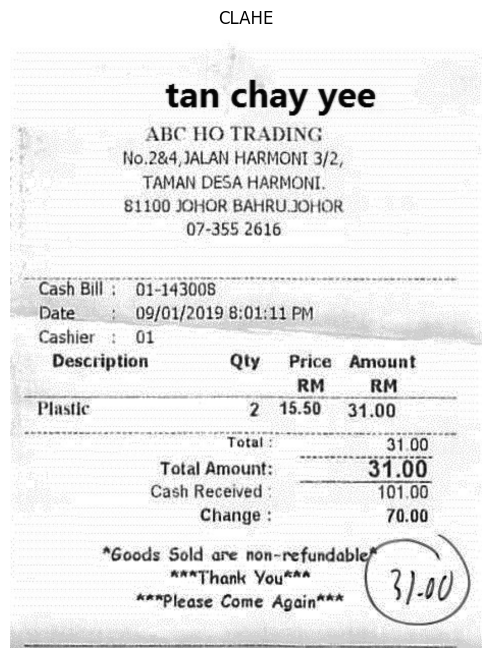

In [ ]:
# Test

contrast = enhance_contrast(gray)

plt.figure(figsize=(8,8))
plt.imshow(contrast, cmap="gray")
plt.title("CLAHE")
plt.axis("off")
plt.show()

In [ ]:
# Sharpen Image

def sharpen_image(image):
    """
    Sharpen image using kernel filtering.
    """

    kernel = np.array([
        [0,-1,0],
        [-1,5,-1],
        [0,-1,0]
    ])

    return cv2.filter2D(image,-1,kernel)

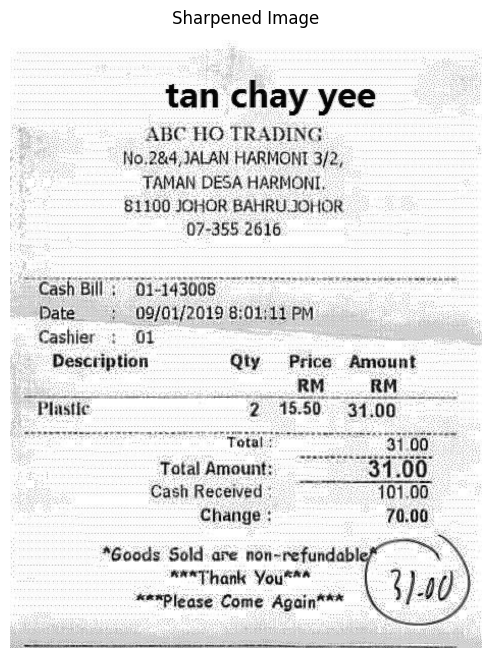

In [ ]:
# Test

sharp = sharpen_image(contrast)

plt.figure(figsize=(8,8))
plt.imshow(sharp,cmap="gray")
plt.title("Sharpened Image")
plt.axis("off")
plt.show()

In [ ]:
# Deskew Image

def deskew_image(image):
    """
    Correct skew in scanned documents.
    """

    coords = np.column_stack(np.where(image > 0))

    if len(coords) == 0:
        return image

    angle = cv2.minAreaRect(coords)[-1]

    if angle < -45:
        angle = 90 + angle
    else:
        angle = angle

    h, w = image.shape

    center = (w // 2, h // 2)

    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        image,
        matrix,
        (w,h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated

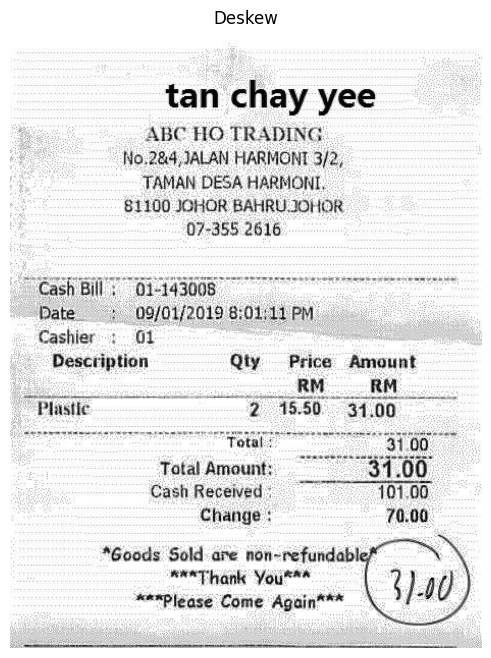

In [ ]:
# Test

deskew = deskew_image(sharp)

plt.figure(figsize=(8,8))
plt.imshow(deskew,cmap="gray")
plt.title("Deskew")
plt.axis("off")
plt.show()

In [ ]:
# Complete Preprocessing Pipeline

def preprocess_document(image_path):
    """
    Complete preprocessing pipeline.
    """

    image = load_image(image_path)

    image = resize_image(image)

    gray = grayscale(image)

    denoise = remove_noise(gray)

    blur = gaussian_blur(denoise)

    contrast = enhance_contrast(blur)

    thresh = adaptive_threshold(contrast)

    morph = morphological_processing(thresh)

    sharp = sharpen_image(morph)

    final = deskew_image(sharp)

    return final

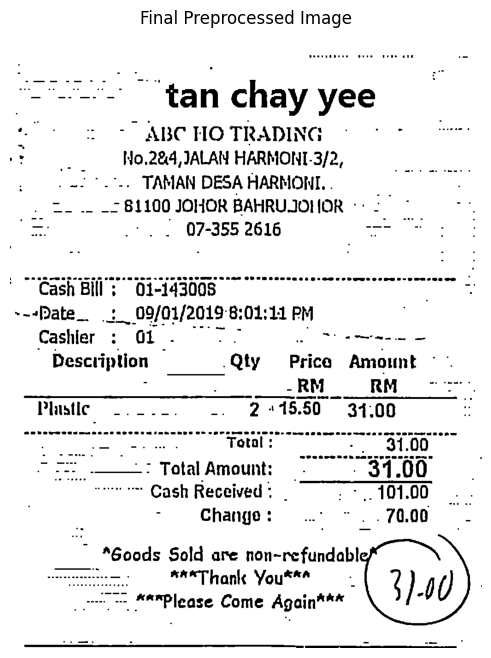

In [ ]:
# Test Pipeline

sample = os.listdir(invoice_path)[0]

image_path = os.path.join(invoice_path, sample)

processed = preprocess_document(image_path)

plt.figure(figsize=(8,8))
plt.imshow(processed,cmap="gray")
plt.title("Final Preprocessed Image")
plt.axis("off")
plt.show()

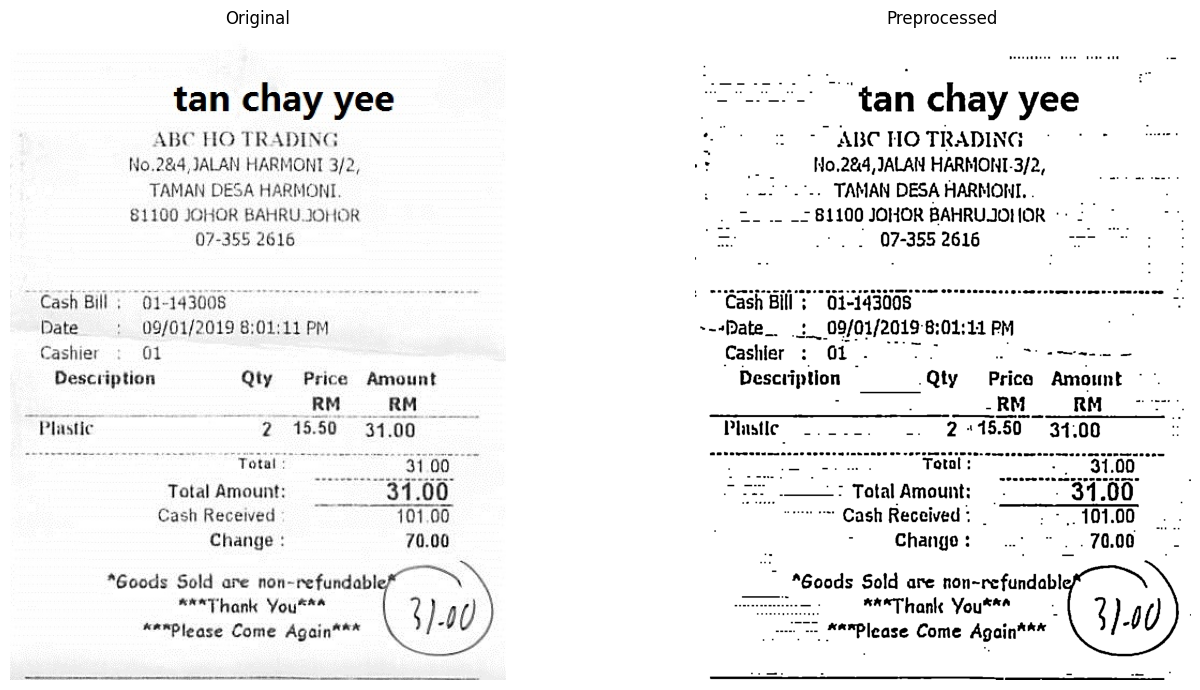

In [ ]:
# Before vs After

original = load_image(image_path)

processed = preprocess_document(image_path)

plt.figure(figsize=(15,7))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed,cmap="gray")
plt.title("Preprocessed")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Batch Processing

def batch_preprocessing(input_folder, output_folder):

    os.makedirs(output_folder, exist_ok=True)

    for file in os.listdir(input_folder):

        path = os.path.join(input_folder, file)

        try:

            processed = preprocess_document(path)

            save_path = os.path.join(output_folder, file)

            cv2.imwrite(save_path, processed)

        except Exception as e:

            print(f"Skipped {file} -> {e}")

    print("Batch preprocessing completed.")

In [ ]:
# Process Invoice Images

batch_preprocessing(
    invoice_path,
    "/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/preprocessed/invoices"
)

Batch preprocessing completed.


In [ ]:
# Process Resume Images

batch_preprocessing(
    resume_path,
    "/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/preprocessed/resumes"
)

Batch preprocessing completed.


In [ ]:
# Process ID Card Images

batch_preprocessing(
    id_path,
    "/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/preprocessed/id_cards"
)

Batch preprocessing completed.


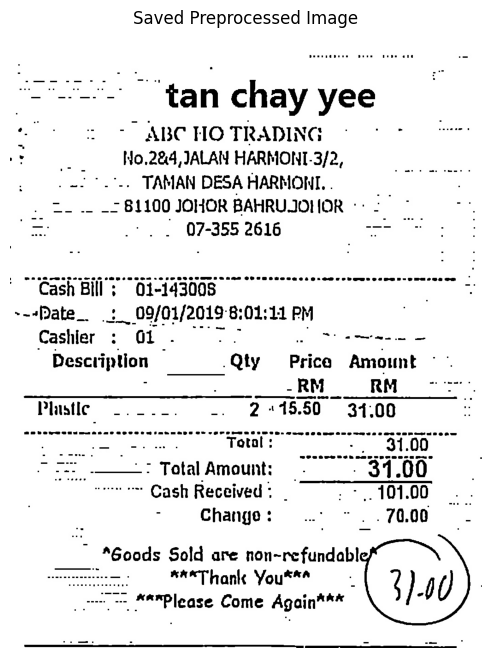

In [ ]:
# Verify Saved Images

processed_invoice_path = "/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/preprocessed/invoices"

sample = os.listdir(processed_invoice_path)[0]

img = cv2.imread(os.path.join(processed_invoice_path, sample),
                 cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,8))
plt.imshow(img, cmap="gray")
plt.title("Saved Preprocessed Image")
plt.axis("off")
plt.show()

In [ ]:
datasets = {
    "invoices": invoice_path,
    "resumes": resume_path,
    "id_cards": id_path,
}

for name, input_folder in datasets.items():
    output_folder = os.path.join("/content/drive/MyDrive/Colab Notebooks/Intelligent_Document_Processing/outputs/preprocessed", name)
    batch_preprocessing(input_folder, output_folder)

Batch preprocessing completed.
Batch preprocessing completed.
Batch preprocessing completed.
